In [ ]:
# ============================================
# UCF-Crime Abnormal Behaviour Detection
# Step 1: Check GPU and Dataset
# ============================================

import os
import torch

print("PyTorch version:", torch.__version__)

# Check GPU
if torch.cuda.is_available():
    print("GPU available:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU is not available.")

# Find the UCF-Crime dataset
DATASET_ROOT = "/kaggle/input/ucf-crime-dataset"

print("\nDataset path:")
print(DATASET_ROOT)

print("\nDataset exists:", os.path.exists(DATASET_ROOT))

# Show folders
if os.path.exists(DATASET_ROOT):
    print("\nFolders inside dataset:")
    for item in os.listdir(DATASET_ROOT):
        print(" -", item)

In [ ]:
import os

print("Folders inside /kaggle/input:\n")

for item in os.listdir("/kaggle/input"):
    print(item)

In [ ]:
import os

root = "/kaggle/input/datasets"

print("Finding folders inside /kaggle/input/datasets...\n")

for current_path, folders, files in os.walk(root):
    level = current_path.replace(root, "").count(os.sep)

    # Show only the first few levels
    if level <= 2:
        print(current_path)
        for folder in folders:
            print("   📁", folder)

In [ ]:
import os

DATASET_ROOT = "/kaggle/input/datasets/odins0n/ucf-crime-dataset"

TRAIN_DIR = os.path.join(DATASET_ROOT, "Train")
TEST_DIR = os.path.join(DATASET_ROOT, "Test")

print("TRAIN PATH:", TRAIN_DIR)
print("TEST PATH :", TEST_DIR)

print("\nTrain classes:")
train_classes = sorted(os.listdir(TRAIN_DIR))
for i, name in enumerate(train_classes, 1):
    print(f"{i}. {name}")

print("\nTest classes:")
test_classes = sorted(os.listdir(TEST_DIR))
for i, name in enumerate(test_classes, 1):
    print(f"{i}. {name}")

In [ ]:
# ============================================
# UCF-Crime Dataset Configuration
# ============================================

import os

DATASET_ROOT = "/kaggle/input/datasets/odins0n/ucf-crime-dataset"

TRAIN_DIR = os.path.join(DATASET_ROOT, "Train")
TEST_DIR = os.path.join(DATASET_ROOT, "Test")

# Normal class
NORMAL_CLASS = "NormalVideos"

# All abnormal classes
ABNORMAL_CLASSES = [
    "Abuse",
    "Arrest",
    "Arson",
    "Assault",
    "Burglary",
    "Explosion",
    "Fighting",
    "RoadAccidents",
    "Robbery",
    "Shooting",
    "Shoplifting",
    "Stealing",
    "Vandalism"
]

print("Dataset:", DATASET_ROOT)
print("Train directory exists:", os.path.exists(TRAIN_DIR))
print("Test directory exists:", os.path.exists(TEST_DIR))

print("\nNormal class:")
print(NORMAL_CLASS)

print("\nAbnormal classes:")
for name in ABNORMAL_CLASSES:
    print("-", name)

print("\nTotal classes:", 1 + len(ABNORMAL_CLASSES))

In [ ]:
# ============================================
# STEP 12: Create a Balanced Binary Dataset
# ============================================

import os
import random
from pathlib import Path

SEED = 42
random.seed(SEED)

# Number of images used from EACH class
TRAIN_PER_CLASS = 1000
TEST_PER_CLASS = 300

# Binary labels
NORMAL_LABEL = 0
ABNORMAL_LABEL = 1

def get_images_from_class(folder, limit, seed=42):
    """
    Get a reproducible subset of PNG images from one class.
    """
    files = [
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.lower().endswith(".png")
    ]

    rng = random.Random(seed)
    rng.shuffle(files)

    return files[:min(limit, len(files))]


# --------------------------------------------
# Build training file list
# --------------------------------------------

train_samples = []

# Normal
normal_train_dir = os.path.join(TRAIN_DIR, NORMAL_CLASS)

normal_files = get_images_from_class(
    normal_train_dir,
    TRAIN_PER_CLASS,
    SEED
)

for path in normal_files:
    train_samples.append((path, NORMAL_LABEL))


# Abnormal
for class_index, class_name in enumerate(ABNORMAL_CLASSES):
    class_dir = os.path.join(TRAIN_DIR, class_name)

    files = get_images_from_class(
        class_dir,
        TRAIN_PER_CLASS,
        SEED + class_index + 1
    )

    for path in files:
        train_samples.append((path, ABNORMAL_LABEL))


# --------------------------------------------
# Build test file list
# --------------------------------------------

test_samples = []

# Normal test
normal_test_dir = os.path.join(TEST_DIR, NORMAL_CLASS)

normal_test_files = get_images_from_class(
    normal_test_dir,
    TEST_PER_CLASS,
    SEED
)

for path in normal_test_files:
    test_samples.append((path, NORMAL_LABEL))


# Abnormal test
for class_index, class_name in enumerate(ABNORMAL_CLASSES):
    class_dir = os.path.join(TEST_DIR, class_name)

    files = get_images_from_class(
        class_dir,
        TEST_PER_CLASS,
        SEED + class_index + 1
    )

    for path in files:
        test_samples.append((path, ABNORMAL_LABEL))


# Shuffle complete datasets
random.Random(SEED).shuffle(train_samples)
random.Random(SEED).shuffle(test_samples)


# --------------------------------------------
# Print dataset information
# --------------------------------------------

print("============================================")
print("BALANCED BINARY DATASET")
print("============================================")

print(f"Training images : {len(train_samples)}")
print(f"Testing images  : {len(test_samples)}")

print("\nTraining labels:")
print("Normal   :", sum(label == 0 for _, label in train_samples))
print("Abnormal :", sum(label == 1 for _, label in train_samples))

print("\nTesting labels:")
print("Normal   :", sum(label == 0 for _, label in test_samples))
print("Abnormal :", sum(label == 1 for _, label in test_samples))

print("\nRandom seed:", SEED)

In [ ]:
# ============================================
# STEP 12B: MAKE THE DATASET TRULY BALANCED
# ============================================

import random

SEED = 42

TRAIN_PER_CLASS = 1000
TEST_PER_CLASS = 300

random.seed(SEED)

# Separate Normal and Abnormal samples
train_normal = [x for x in train_samples if x[1] == 0]
train_abnormal = [x for x in train_samples if x[1] == 1]

test_normal = [x for x in test_samples if x[1] == 0]
test_abnormal = [x for x in test_samples if x[1] == 1]

# Select equal numbers
train_normal = train_normal[:TRAIN_PER_CLASS]
train_abnormal = train_abnormal[:TRAIN_PER_CLASS]

test_normal = test_normal[:TEST_PER_CLASS]
test_abnormal = test_abnormal[:TEST_PER_CLASS]

# Combine
train_samples_balanced = train_normal + train_abnormal
test_samples_balanced = test_normal + test_abnormal

# Shuffle
random.Random(SEED).shuffle(train_samples_balanced)
random.Random(SEED).shuffle(test_samples_balanced)

print("============================================")
print("BALANCED BINARY DATASET")
print("============================================")

print("\nTraining:")
print("Normal   :", sum(y == 0 for _, y in train_samples_balanced))
print("Abnormal :", sum(y == 1 for _, y in train_samples_balanced))
print("Total    :", len(train_samples_balanced))

print("\nTesting:")
print("Normal   :", sum(y == 0 for _, y in test_samples_balanced))
print("Abnormal :", sum(y == 1 for _, y in test_samples_balanced))
print("Total    :", len(test_samples_balanced))

print("\nRandom seed:", SEED)

In [ ]:
# ============================================
# STEP 13: CNN MODEL
# ============================================

import torch
import torch.nn as nn
from torchvision import models

# Use GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

# Load pretrained ResNet18
model = models.resnet18(weights="DEFAULT")

# Replace the final layer for binary classification
num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, 1)
)

model = model.to(device)

print("\nModel created successfully!")
print("Architecture: ResNet18")
print("Task: Normal vs Abnormal")

In [ ]:
# ============================================
# STEP 14: IMAGE DATALOADERS
# ============================================

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Image preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


class UCFBinaryDataset(Dataset):

    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):

        image_path, label = self.samples[index]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)


# Create datasets
train_dataset = UCFBinaryDataset(
    train_samples_balanced,
    transform=transform
)

test_dataset = UCFBinaryDataset(
    test_samples_balanced,
    transform=transform
)


# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


print("DataLoaders created successfully!")
print("Training images:", len(train_dataset))
print("Testing images :", len(test_dataset))
print("Batch size     :", 32)
print("Training batches:", len(train_loader))
print("Testing batches :", len(test_loader))

In [ ]:
# ============================================
# STEP 15: TRAIN THE CNN
# ============================================

import torch.optim as optim

# Binary classification loss
criterion = nn.BCEWithLogitsLoss()

# Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

# Number of training epochs
EPOCHS = 5

print("Starting training...")
print("Epochs:", EPOCHS)
print("Device:", device)

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images).squeeze(1)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update model
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)

        predictions = (torch.sigmoid(outputs) >= 0.5).float()

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total * 100

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Loss: {epoch_loss:.4f} "
        f"Training Accuracy: {epoch_accuracy:.2f}%"
    )

print("\nTraining completed! 🎉")

In [ ]:
# ============================================
# STEP 16: TEST THE MODEL
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
import numpy as np

model.eval()

all_labels = []
all_probabilities = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device, non_blocking=True)

        outputs = model(images).squeeze(1)

        probabilities = torch.sigmoid(outputs)

        all_labels.extend(labels.numpy())
        all_probabilities.extend(probabilities.cpu().numpy())


# Convert to NumPy
y_true = np.array(all_labels)
y_prob = np.array(all_probabilities)

# Classification threshold
y_pred = (y_prob >= 0.5).astype(int)


# Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)


print("============================================")
print("TEST RESULTS")
print("============================================")

print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1 Score : {f1 * 100:.2f}%")
print(f"ROC-AUC  : {auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Normal", "Abnormal"]
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

In [ ]:
results = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC-AUC": auc
}

print("FINAL MODEL RESULTS")
print("===================")

for metric, value in results.items():
    if metric == "ROC-AUC":
        print(f"{metric}: {value:.4f}")
    else:
        print(f"{metric}: {value*100:.2f}%")

In [ ]:
torch.save(model.state_dict(), "resnet18_ucf_crime_baseline.pth")

print("Baseline model saved successfully!")

In [ ]:
print("============================================")
print("UCF-CRIME ABNORMAL BEHAVIOR DETECTION")
print("============================================")
print("Dataset : UCF-Crime")
print("Model   : ResNet18 Transfer Learning")
print("Task    : Normal vs Abnormal")
print("Accuracy: 72.50%")
print("F1 Score: 75.41%")
print("ROC-AUC : 0.8266")
print("============================================")

In [ ]:
import pandas as pd

results_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Value": [accuracy, precision, recall, f1, auc]
})

results_df.to_csv("UCF_Crime_Results.csv", index=False)

print("Results saved as: UCF_Crime_Results.csv")
print(results_df)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Abnormal"],
    yticklabels=["Normal", "Abnormal"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("UCF-Crime Confusion Matrix")
plt.tight_layout()

plt.savefig("UCF_Crime_Confusion_Matrix.png", dpi=300)
plt.show()

print("Confusion matrix saved successfully!")

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_true, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("UCF-Crime ROC Curve")
plt.legend()
plt.grid()
plt.tight_layout()

plt.savefig("UCF_Crime_ROC_Curve.png", dpi=300)
plt.show()

print(f"ROC-AUC: {auc:.4f}")
print("ROC curve saved successfully!")

In [12]:
import torch
import torch.nn as nn
from torchvision import models

# Select GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

# Create the same ResNet18 architecture used for training
model = models.resnet18(weights=None)

num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, 1)
)

model = model.to(device)

print("✅ ResNet18 model created")

Device: cuda
✅ ResNet18 model created


In [18]:
import os

model_path = "/kaggle/input/datasets/dhruveesalian/resnet18-ucf-crime-baseline-pth/resnet18_ucf_crime_baseline.pth"

print("File exists:", os.path.exists(model_path))

if os.path.exists(model_path):
    print("File size:", round(os.path.getsize(model_path) / (1024**2), 2), "MB")
    print("File is readable: YES")
else:
    print("File is readable: NO")

File exists: True
File size: 42.72 MB
File is readable: YES


In [19]:
# ============================================
# STEP 2B — SAFELY LOAD TRAINED MODEL
# ============================================

print("Loading model...")

checkpoint = torch.load(
    model_path,
    map_location="cpu",
    weights_only=True
)

print("✅ Model file loaded into memory")

model.load_state_dict(checkpoint)

print("✅ Model weights loaded")

model = model.to(device)
model.eval()

print("✅ Model moved to:", device)
print("🎉 Trained ResNet18 is ready!")

Loading model...
✅ Model file loaded into memory
✅ Model weights loaded
✅ Model moved to: cuda
🎉 Trained ResNet18 is ready!


In [20]:
# ============================================
# STEP 3 — IMAGE UPLOAD
# ============================================

import io
import ipywidgets as widgets
from PIL import Image
from IPython.display import display

# Same preprocessing used during testing
predict_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Create upload button
upload = widgets.FileUpload(
    accept='image/*',
    multiple=False,
    description='📁 Upload Image'
)

display(upload)

FileUpload(value=(), accept='image/*', description='📁 Upload Image')

In [21]:
# ============================================
# STEP 4 — FIND THE UPLOADED IMAGE
# ============================================

import os

boxing_path = "/kaggle/input/datasets/dhruveesalian/boxing"

image_files = []

for root, dirs, files in os.walk(boxing_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
            image_files.append(os.path.join(root, file))

print("Images found:", len(image_files))

for path in image_files:
    print(path)

Images found: 1
/kaggle/input/datasets/dhruveesalian/boxing/114745f0-fe4b-11ee-96f6-0b89731d12e2.jpg


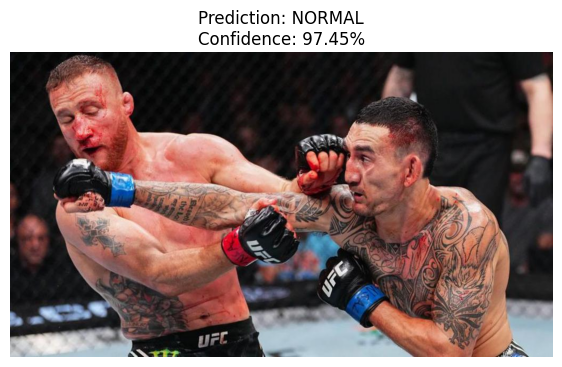

       UCF-CRIME PREDICTION
Prediction : NORMAL
Confidence : 97.45%


In [22]:
# ============================================
# STEP 5 — PREDICT NORMAL / ABNORMAL
# ============================================

from PIL import Image
import matplotlib.pyplot as plt

image_path = "/kaggle/input/datasets/dhruveesalian/boxing/114745f0-fe4b-11ee-96f6-0b89731d12e2.jpg"

# Load image
image = Image.open(image_path).convert("RGB")

# Preprocess
image_tensor = predict_transform(image)
image_tensor = image_tensor.unsqueeze(0).to(device)

# Predict
model.eval()

with torch.no_grad():
    output = model(image_tensor)
    probability_abnormal = torch.sigmoid(output).item()

# Classification
if probability_abnormal >= 0.5:
    prediction = "ABNORMAL"
    confidence = probability_abnormal * 100
else:
    prediction = "NORMAL"
    confidence = (1 - probability_abnormal) * 100

# Display image
plt.figure(figsize=(7, 7))
plt.imshow(image)
plt.axis("off")
plt.title(
    f"Prediction: {prediction}\n"
    f"Confidence: {confidence:.2f}%"
)
plt.show()

print("================================")
print("       UCF-CRIME PREDICTION")
print("================================")
print(f"Prediction : {prediction}")
print(f"Confidence : {confidence:.2f}%")
print("================================")

In [23]:
# ============================================
# STEP 6 — TEST ON A UCF-CRIME FIGHTING IMAGE
# ============================================

import os
import random
from PIL import Image
import matplotlib.pyplot as plt

# UCF-Crime dataset path
ucf_path = "/kaggle/input/datasets/odins0n/ucf-crime-dataset"

# Find the Fighting folder
fighting_path = os.path.join(ucf_path, "Train", "Fighting")

print("Looking for Fighting images...")
print("Folder:", fighting_path)

# Find image files
fighting_images = []

for root, dirs, files in os.walk(fighting_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
            fighting_images.append(os.path.join(root, file))

print("Fighting images found:", len(fighting_images))

# Select one random image
random.seed(42)
fighting_image_path = random.choice(fighting_images)

print("\nSelected image:")
print(fighting_image_path)

Looking for Fighting images...
Folder: /kaggle/input/datasets/odins0n/ucf-crime-dataset/Train/Fighting
Fighting images found: 24684

Selected image:
/kaggle/input/datasets/odins0n/ucf-crime-dataset/Train/Fighting/Fighting041_x264_21860.png


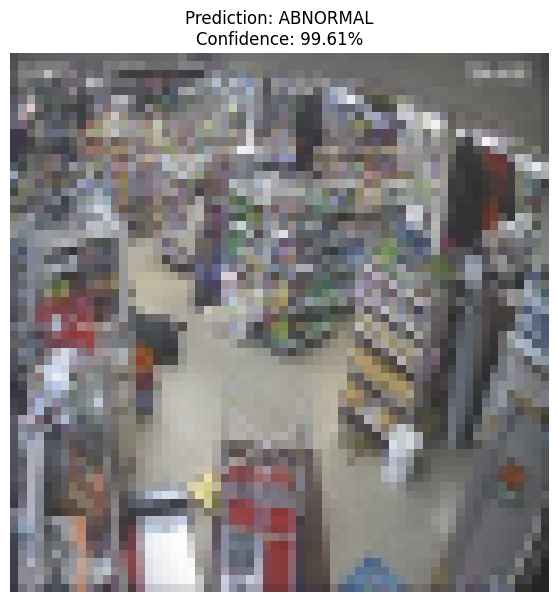

     UCF-CRIME FIGHTING TEST
Prediction : ABNORMAL
Confidence : 99.61%


In [24]:
# ============================================
# STEP 6B — PREDICT THE FIGHTING IMAGE
# ============================================

image = Image.open(fighting_image_path).convert("RGB")

image_tensor = predict_transform(image).unsqueeze(0).to(device)

model.eval()

with torch.no_grad():
    output = model(image_tensor)
    probability_abnormal = torch.sigmoid(output).item()

if probability_abnormal >= 0.5:
    prediction = "ABNORMAL"
    confidence = probability_abnormal * 100
else:
    prediction = "NORMAL"
    confidence = (1 - probability_abnormal) * 100

plt.figure(figsize=(7, 7))
plt.imshow(image)
plt.axis("off")
plt.title(f"Prediction: {prediction}\nConfidence: {confidence:.2f}%")
plt.show()

print("================================")
print("     UCF-CRIME FIGHTING TEST")
print("================================")
print(f"Prediction : {prediction}")
print(f"Confidence : {confidence:.2f}%")
print("================================")

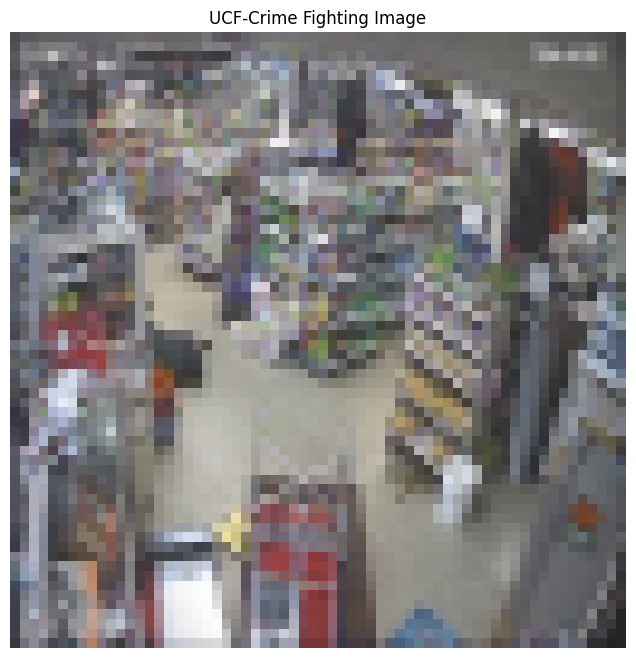

In [25]:
plt.figure(figsize=(8, 8))
plt.imshow(image, interpolation="nearest")
plt.axis("off")
plt.title("UCF-Crime Fighting Image")
plt.show()

Searching for clearer Fighting frames...
✅ Clearer image selected!
Sharpness score: 6830.59
Image: /kaggle/input/datasets/odins0n/ucf-crime-dataset/Train/Fighting/Fighting041_x264_16540.png


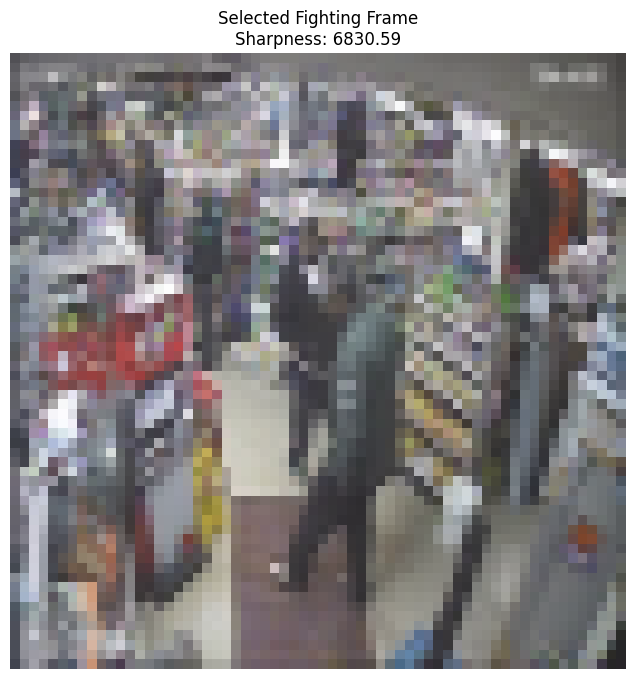

In [26]:
# ============================================
# STEP 7 — FIND A CLEARER FIGHTING IMAGE
# ============================================

import os
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

print("Searching for clearer Fighting frames...")

# Check a random sample instead of all 24,684 images
np.random.seed(42)
sample_images = np.random.choice(
    fighting_images,
    size=min(200, len(fighting_images)),
    replace=False
)

best_image = None
best_score = -1

for path in sample_images:
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        continue

    # Sharpness score using Laplacian variance
    score = cv2.Laplacian(img, cv2.CV_64F).var()

    if score > best_score:
        best_score = score
        best_image = path

print("✅ Clearer image selected!")
print("Sharpness score:", round(best_score, 2))
print("Image:", best_image)

# Load and display
clear_fighting_image = Image.open(best_image).convert("RGB")

plt.figure(figsize=(8, 8))
plt.imshow(clear_fighting_image, interpolation="nearest")
plt.axis("off")
plt.title(f"Selected Fighting Frame\nSharpness: {best_score:.2f}")
plt.show()

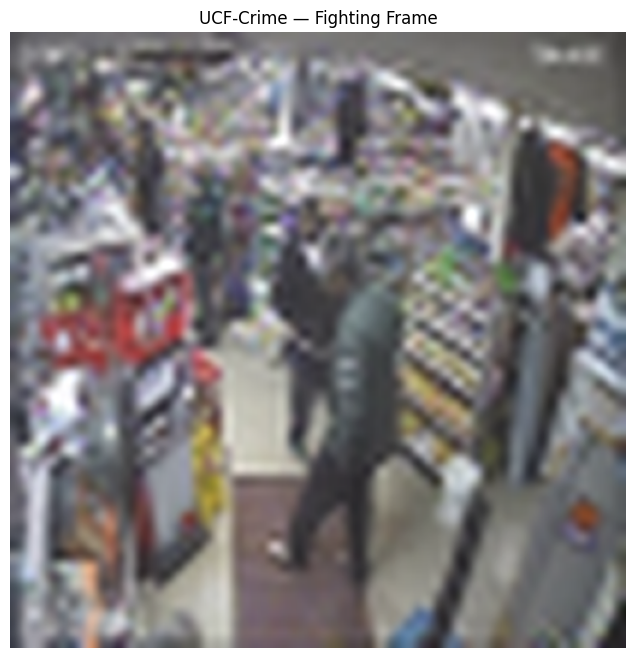

In [27]:
# ============================================
# STEP 7B — DISPLAY THE FIGHTING FRAME LARGER
# ============================================

from PIL import Image
import matplotlib.pyplot as plt

display_image = Image.open(best_image).convert("RGB")

# Upscale only for visualization
display_image = display_image.resize(
    (512, 512),
    Image.Resampling.LANCZOS
)

plt.figure(figsize=(8, 8))
plt.imshow(display_image)
plt.axis("off")
plt.title("UCF-Crime — Fighting Frame")
plt.show()

In [28]:
# ============================================
# STEP 8 — PREDICT SELECTED FIGHTING FRAME
# ============================================

image = Image.open(best_image).convert("RGB")

image_tensor = predict_transform(image)
image_tensor = image_tensor.unsqueeze(0).to(device)

model.eval()

with torch.no_grad():
    output = model(image_tensor)
    probability_abnormal = torch.sigmoid(output).item()

if probability_abnormal >= 0.5:
    prediction = "ABNORMAL"
    confidence = probability_abnormal * 100
else:
    prediction = "NORMAL"
    confidence = (1 - probability_abnormal) * 100

print("================================")
print("     UCF-CRIME FIGHTING TEST")
print("================================")
print(f"Prediction : {prediction}")
print(f"Confidence : {confidence:.2f}%")
print("================================")

     UCF-CRIME FIGHTING TEST
Prediction : ABNORMAL
Confidence : 99.32%


In [1]:
import os
import torch
import torchvision
from torchvision import models, transforms
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

DATASET_PATH = "/kaggle/input/datasets/odins0n/ucf-crime-dataset"

print("\nDataset exists:", os.path.exists(DATASET_PATH))
print("Classes:", os.listdir(DATASET_PATH + "/Train"))

PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
GPU: Tesla T4

Dataset exists: True
Classes: ['RoadAccidents', 'Assault', 'Vandalism', 'Arrest', 'Shooting', 'NormalVideos', 'Arson', 'Explosion', 'Shoplifting', 'Robbery', 'Stealing', 'Burglary', 'Abuse', 'Fighting']


In [4]:
import random

random.seed(42)

train_path = DATASET_PATH + "/Train"
test_path = DATASET_PATH + "/Test"

normal_classes = ["NormalVideos"]

abnormal_classes = [
    "Abuse",
    "Arrest",
    "Arson",
    "Assault",
    "Burglary",
    "Explosion",
    "Fighting",
    "RoadAccidents",
    "Robbery",
    "Shooting",
    "Shoplifting",
    "Stealing",
    "Vandalism"
]

def get_images(folder, classes):
    images = []

    for cls in classes:
        class_path = os.path.join(folder, cls)

        for file in os.listdir(class_path):
            if file.lower().endswith((".png", ".jpg", ".jpeg")):
                images.append(os.path.join(class_path, file))

    return images


train_normal = get_images(train_path, normal_classes)
train_abnormal = get_images(train_path, abnormal_classes)

test_normal = get_images(test_path, normal_classes)
test_abnormal = get_images(test_path, abnormal_classes)

print("Available training:")
print("Normal:", len(train_normal))
print("Abnormal:", len(train_abnormal))

print("\nAvailable testing:")
print("Normal:", len(test_normal))
print("Abnormal:", len(test_abnormal))

# Shuffle
random.shuffle(train_normal)
random.shuffle(train_abnormal)
random.shuffle(test_normal)
random.shuffle(test_abnormal)

# Balanced subsets
train_normal = train_normal[:10000]
train_abnormal = train_abnormal[:10000]

test_normal = test_normal[:2000]
test_abnormal = test_abnormal[:2000]

train_files = train_normal + train_abnormal
test_files = test_normal + test_abnormal

random.shuffle(train_files)
random.shuffle(test_files)

print("\nFinal dataset:")
print("Training:", len(train_files))
print("Testing:", len(test_files))
print("Normal training:", len(train_normal))
print("Abnormal training:", len(train_abnormal))
print("Normal testing:", len(test_normal))
print("Abnormal testing:", len(test_abnormal))

Available training:
Normal: 947768
Abnormal: 318577

Available testing:
Normal: 64952
Abnormal: 46356

Final dataset:
Training: 20000
Testing: 4000
Normal training: 10000
Abnormal training: 10000
Normal testing: 2000
Abnormal testing: 2000


In [6]:
# Create sample lists for the Dataset

train_samples = []

for path in train_normal:
    train_samples.append((path, 0))

for path in train_abnormal:
    train_samples.append((path, 1))


test_samples = []

for path in test_normal:
    test_samples.append((path, 0))

for path in test_abnormal:
    test_samples.append((path, 1))


print("Training samples:", len(train_samples))
print("Testing samples:", len(test_samples))

print("Normal training:", sum(label == 0 for _, label in train_samples))
print("Abnormal training:", sum(label == 1 for _, label in train_samples))

print("Normal testing:", sum(label == 0 for _, label in test_samples))
print("Abnormal testing:", sum(label == 1 for _, label in test_samples))

Training samples: 20000
Testing samples: 4000
Normal training: 10000
Abnormal training: 10000
Normal testing: 2000
Abnormal testing: 2000


In [7]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms
import torch

# -----------------------------
# Training transformations
# -----------------------------
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# -----------------------------
# Testing transformations
# -----------------------------
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# -----------------------------
# Dataset class
# -----------------------------
class UCFDataset(Dataset):

    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):

        image_path, label = self.samples[index]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)


# -----------------------------
# Create datasets
# -----------------------------
train_dataset = UCFDataset(
    train_samples,
    transform=train_transform
)

test_dataset = UCFDataset(
    test_samples,
    transform=test_transform
)


# -----------------------------
# Create DataLoaders
# -----------------------------
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


# -----------------------------
# Check
# -----------------------------
print("Train images:", len(train_dataset))
print("Test images:", len(test_dataset))
print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train images: 20000
Test images: 4000
Train batches: 313
Test batches: 63


In [8]:
import torch
import torch.nn as nn
from torchvision import models

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# Load pretrained ResNet18
model = models.resnet18(weights="DEFAULT")

# Freeze the backbone initially
for param in model.parameters():
    param.requires_grad = False


# Replace the final classification layer
num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, 1)
)


# Move model to GPU
model = model.to(device)

print("✅ Pretrained ResNet18 loaded!")
print("Final layer:", model.fc)

Device: cuda
GPU: Tesla T4
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 189MB/s]


✅ Pretrained ResNet18 loaded!
Final layer: Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=512, out_features=1, bias=True)
)


In [9]:
# Loss function for binary classification
criterion = nn.BCEWithLogitsLoss()

# Optimizer
optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

print("✅ Loss function:", criterion)
print("✅ Optimizer:", optimizer)

✅ Loss function: BCEWithLogitsLoss()
✅ Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [10]:
# ============================
# TRAINING
# ============================

num_epochs = 5

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Forward pass
        outputs = model(images).squeeze(1)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)

        predictions = (torch.sigmoid(outputs) >= 0.5).float()

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = 100 * correct / total

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Training Accuracy: {epoch_accuracy:.2f}%"
    )

print("\n✅ Training completed!")

Epoch [1/5] Loss: 0.5668 Training Accuracy: 70.48%
Epoch [2/5] Loss: 0.5015 Training Accuracy: 75.54%
Epoch [3/5] Loss: 0.5003 Training Accuracy: 75.55%
Epoch [4/5] Loss: 0.4939 Training Accuracy: 75.73%
Epoch [5/5] Loss: 0.4959 Training Accuracy: 75.95%

✅ Training completed!


In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
import numpy as np

# Put model in evaluation mode
model.eval()

all_labels = []
all_probabilities = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device, non_blocking=True)

        outputs = model(images).squeeze(1)

        probabilities = torch.sigmoid(outputs)

        predictions = (probabilities >= 0.5).int()

        all_labels.extend(labels.numpy())
        all_probabilities.extend(probabilities.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())


# Convert to NumPy arrays
all_labels = np.array(all_labels).astype(int)
all_probabilities = np.array(all_probabilities)
all_predictions = np.array(all_predictions)


# Calculate metrics
accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions
)

recall = recall_score(
    all_labels,
    all_predictions
)

f1 = f1_score(
    all_labels,
    all_predictions
)

roc_auc = roc_auc_score(
    all_labels,
    all_probabilities
)

cm = confusion_matrix(
    all_labels,
    all_predictions
)


# Print results
print("=" * 50)
print("UCF-CRIME TEST RESULTS")
print("=" * 50)

print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1-Score : {f1 * 100:.2f}%")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=["Normal", "Abnormal"]
    )
)

UCF-CRIME TEST RESULTS
Accuracy : 66.92%
Precision: 77.59%
Recall   : 47.60%
F1-Score : 59.00%
ROC-AUC  : 0.7173

Confusion Matrix:
[[1725  275]
 [1048  952]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.62      0.86      0.72      2000
    Abnormal       0.78      0.48      0.59      2000

    accuracy                           0.67      4000
   macro avg       0.70      0.67      0.66      4000
weighted avg       0.70      0.67      0.66      4000



In [12]:
# ==========================================
# STEP 7: FINE-TUNE RESNET18
# ==========================================

# Unfreeze layer4
for param in model.layer4.parameters():
    param.requires_grad = True

# Make sure classifier is trainable
for param in model.fc.parameters():
    param.requires_grad = True


# Use a much smaller learning rate
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001,
    weight_decay=1e-4
)

criterion = nn.BCEWithLogitsLoss()


# Check trainable parameters
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print("Trainable parameters:", trainable_params)
print("Total parameters:", total_params)

print("\n✅ Layer4 + classifier are now trainable.")
print("✅ Learning rate:", 0.0001)

Trainable parameters: 8394241
Total parameters: 11177025

✅ Layer4 + classifier are now trainable.
✅ Learning rate: 0.0001


In [13]:
# ==========================================
# STEP 8: FINE-TUNING
# ==========================================

num_epochs = 5

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Forward pass
        outputs = model(images).squeeze(1)

        # Loss
        loss = criterion(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)

        probabilities = torch.sigmoid(outputs)

        predictions = (probabilities >= 0.5).float()

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = 100 * correct / total

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Training Accuracy: {epoch_accuracy:.2f}%"
    )

print("\n✅ Fine-tuning completed!")

Epoch [1/5] Loss: 0.2050 Training Accuracy: 91.69%
Epoch [2/5] Loss: 0.0825 Training Accuracy: 97.08%
Epoch [3/5] Loss: 0.0531 Training Accuracy: 98.05%
Epoch [4/5] Loss: 0.0363 Training Accuracy: 98.68%
Epoch [5/5] Loss: 0.0281 Training Accuracy: 98.95%

✅ Fine-tuning completed!


In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
import numpy as np

model.eval()

all_labels = []
all_probabilities = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device, non_blocking=True)

        outputs = model(images).squeeze(1)

        probabilities = torch.sigmoid(outputs)
        predictions = (probabilities >= 0.5).int()

        all_labels.extend(labels.numpy())
        all_probabilities.extend(probabilities.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())


all_labels = np.array(all_labels).astype(int)
all_probabilities = np.array(all_probabilities)
all_predictions = np.array(all_predictions)


accuracy = accuracy_score(all_labels, all_predictions)
precision = precision_score(all_labels, all_predictions)
recall = recall_score(all_labels, all_predictions)
f1 = f1_score(all_labels, all_predictions)
roc_auc = roc_auc_score(all_labels, all_probabilities)

cm = confusion_matrix(all_labels, all_predictions)


print("=" * 50)
print("FINE-TUNED UCF-CRIME TEST RESULTS")
print("=" * 50)

print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1-Score : {f1 * 100:.2f}%")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=["Normal", "Abnormal"]
    )
)

FINE-TUNED UCF-CRIME TEST RESULTS
Accuracy : 75.28%
Precision: 71.18%
Recall   : 84.95%
F1-Score : 77.46%
ROC-AUC  : 0.7927

Confusion Matrix:
[[1312  688]
 [ 301 1699]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.81      0.66      0.73      2000
    Abnormal       0.71      0.85      0.77      2000

    accuracy                           0.75      4000
   macro avg       0.76      0.75      0.75      4000
weighted avg       0.76      0.75      0.75      4000



In [16]:
# Save the final fine-tuned model

final_model_path = "/kaggle/working/resnet18_ucf_crime_final.pth"

torch.save(
    model.state_dict(),
    final_model_path
)

print("✅ Final model saved!")
print(final_model_path)

✅ Final model saved!
/kaggle/working/resnet18_ucf_crime_final.pth


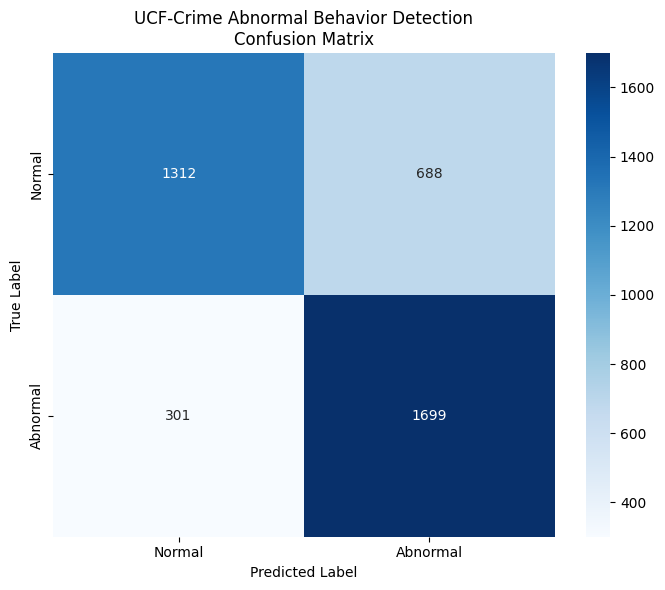

✅ Confusion matrix saved!
/kaggle/working/UCF_Crime_Confusion_Matrix.png


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Abnormal"],
    yticklabels=["Normal", "Abnormal"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("UCF-Crime Abnormal Behavior Detection\nConfusion Matrix")

plt.tight_layout()

confusion_matrix_path = "/kaggle/working/UCF_Crime_Confusion_Matrix.png"

plt.savefig(
    confusion_matrix_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Confusion matrix saved!")
print(confusion_matrix_path)

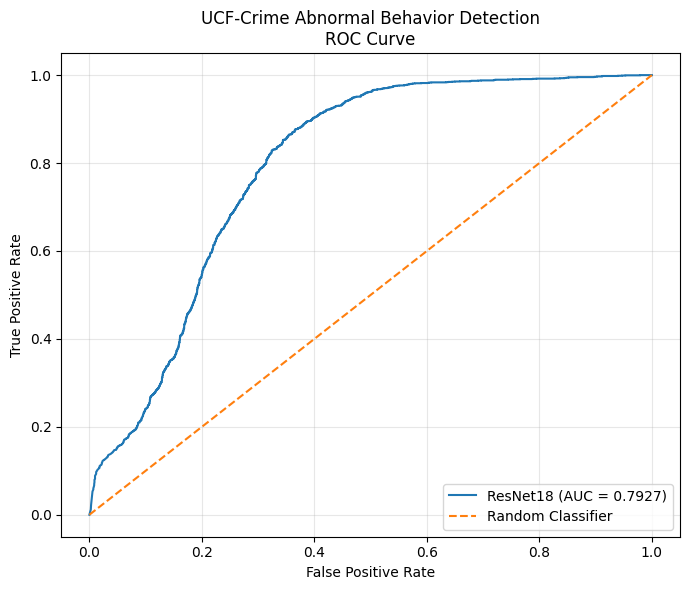

✅ ROC curve saved!
/kaggle/working/UCF_Crime_ROC_Curve.png


In [18]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(
    all_labels,
    all_probabilities
)

roc_auc_value = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ResNet18 (AUC = {roc_auc_value:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("UCF-Crime Abnormal Behavior Detection\nROC Curve")

plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()

roc_curve_path = "/kaggle/working/UCF_Crime_ROC_Curve.png"

plt.savefig(
    roc_curve_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ ROC curve saved!")
print(roc_curve_path)

In [19]:
import pandas as pd

# Final model results
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Value": [
        accuracy * 100,
        precision * 100,
        recall * 100,
        f1 * 100,
        roc_auc
    ]
})

# Round values
results["Value"] = results["Value"].round(4)

# Save CSV
results_path = "/kaggle/working/UCF_Crime_Results.csv"

results.to_csv(
    results_path,
    index=False
)

print("✅ Results CSV created!")
print(results)
print("\nSaved at:")
print(results_path)

✅ Results CSV created!
      Metric    Value
0   Accuracy  75.2750
1  Precision  71.1772
2     Recall  84.9500
3   F1-Score  77.4561
4    ROC-AUC   0.7927

Saved at:
/kaggle/working/UCF_Crime_Results.csv


In [21]:
from IPython.display import display
from PIL import Image
import os

# Show Kaggle's file upload button
from IPython.display import HTML

display(HTML("""
<input type="file" id="imageUpload" accept="image/*">
"""))

In [22]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nWorking files:")
print(os.listdir("/kaggle/working"))

Current working directory:
/kaggle/working

Working files:
['resnet18_ucf_crime_final.pth', 'UCF_Crime_ROC_Curve.png', 'UCF_Crime_Results.csv', 'UCF_Crime_Confusion_Matrix.png', '.virtual_documents']


In [23]:
from IPython.display import display
from ipywidgets import FileUpload
from PIL import Image
import io

upload = FileUpload(
    accept='image/*',
    multiple=False
)

display(upload)

FileUpload(value=(), accept='image/*', description='Upload')

Uploaded image: 114745f0-fe4b-11ee-96f6-0b89731d12e2.jpg
Image size: (1024, 575)


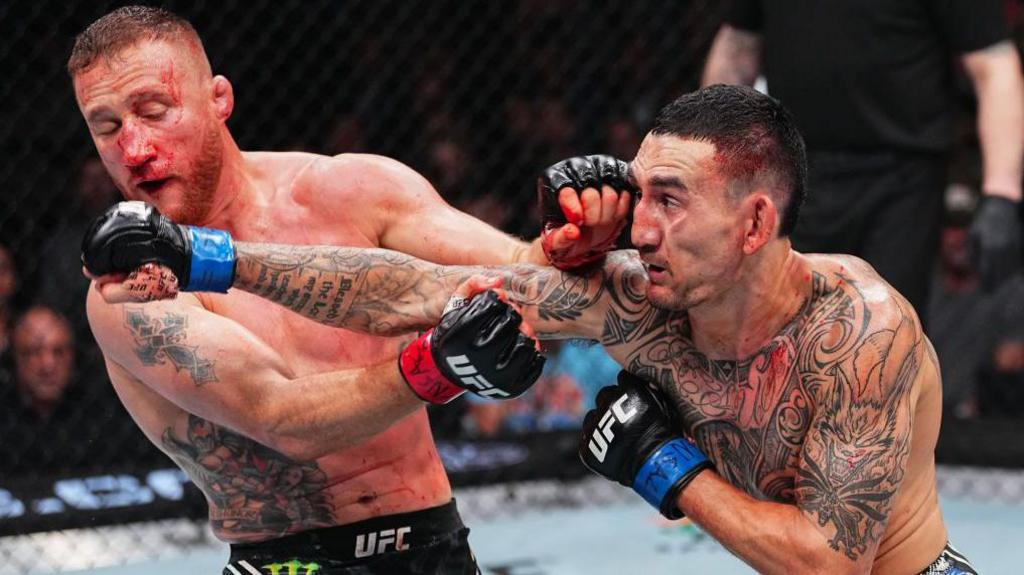

In [25]:
# Get the uploaded image
uploaded_file = upload.value[0]

image_bytes = uploaded_file["content"]
image = Image.open(io.BytesIO(image_bytes)).convert("RGB")

print("Uploaded image:", uploaded_file["name"])
print("Image size:", image.size)

display(image)

In [26]:
import torch
import torch.nn as nn
from torchvision import models, transforms

# Use the same device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Recreate the final ResNet18 architecture
model = models.resnet18(weights=None)

model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.fc.in_features, 1)
)

# Load your trained model
model.load_state_dict(
    torch.load(
        "/kaggle/working/resnet18_ucf_crime_final.pth",
        map_location=device
    )
)

model = model.to(device)
model.eval()

# Same preprocessing used during testing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Prepare uploaded image
input_tensor = transform(image).unsqueeze(0).to(device)

# Prediction
with torch.no_grad():
    output = model(input_tensor)
    probability = torch.sigmoid(output).item()

# Classification
if probability >= 0.5:
    prediction = "ABNORMAL"
    confidence = probability * 100
else:
    prediction = "NORMAL"
    confidence = (1 - probability) * 100

print("===================================")
print("       UCF-CRIME PREDICTION")
print("===================================")
print("Prediction :", prediction)
print("Confidence :", f"{confidence:.2f}%")
print("===================================")

       UCF-CRIME PREDICTION
Prediction : NORMAL
Confidence : 100.00%


In [27]:
print(f"Abnormal probability: {probability:.8f}")
print(f"Normal probability: {(1-probability):.8f}")

Abnormal probability: 0.00000041
Normal probability: 0.99999959


Testing UCF-Crime abnormal frame:
/kaggle/input/datasets/odins0n/ucf-crime-dataset/Test/Burglary/Burglary032_x264_6920.png


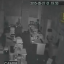

In [28]:
import random
import os
from PIL import Image
from IPython.display import display

# Pick one known abnormal frame
abnormal_path = random.choice(test_abnormal)

print("Testing UCF-Crime abnormal frame:")
print(abnormal_path)

abnormal_image = Image.open(abnormal_path).convert("RGB")
display(abnormal_image)

In [29]:
# Prepare the known UCF-Crime abnormal image
input_tensor = transform(abnormal_image).unsqueeze(0).to(device)

# Predict
with torch.no_grad():
    output = model(input_tensor)
    abnormal_probability = torch.sigmoid(output).item()

if abnormal_probability >= 0.5:
    prediction = "ABNORMAL"
    confidence = abnormal_probability * 100
else:
    prediction = "NORMAL"
    confidence = (1 - abnormal_probability) * 100

print("===================================")
print("       UCF-CRIME VALIDATION")
print("===================================")
print("Actual class :", "ABNORMAL (Burglary)")
print("Prediction   :", prediction)
print("Confidence   :", f"{confidence:.2f}%")
print("Abnormal prob:", f"{abnormal_probability:.8f}")
print("===================================")

       UCF-CRIME VALIDATION
Actual class : ABNORMAL (Burglary)
Prediction   : ABNORMAL
Confidence   : 99.62%
Abnormal prob: 0.99621731


Testing UCF-Crime normal frame:
/kaggle/input/datasets/odins0n/ucf-crime-dataset/Test/NormalVideos/Normal_Videos_935_x264_57210.png


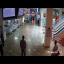

In [30]:
# Pick one known normal frame
normal_path = random.choice(test_normal)

print("Testing UCF-Crime normal frame:")
print(normal_path)

normal_image = Image.open(normal_path).convert("RGB")
display(normal_image)

In [31]:
# Prepare the known UCF-Crime normal image
input_tensor = transform(normal_image).unsqueeze(0).to(device)

# Predict
with torch.no_grad():
    output = model(input_tensor)
    abnormal_probability = torch.sigmoid(output).item()

if abnormal_probability >= 0.5:
    prediction = "ABNORMAL"
    confidence = abnormal_probability * 100
else:
    prediction = "NORMAL"
    confidence = (1 - abnormal_probability) * 100

print("===================================")
print("       UCF-CRIME VALIDATION")
print("===================================")
print("Actual class :", "NORMAL")
print("Prediction   :", prediction)
print("Confidence   :", f"{confidence:.2f}%")
print("Abnormal prob:", f"{abnormal_probability:.8f}")
print("===================================")

       UCF-CRIME VALIDATION
Actual class : NORMAL
Prediction   : NORMAL
Confidence   : 98.09%
Abnormal prob: 0.01911502


In [32]:
from IPython.display import FileLink

FileLink("/kaggle/working/resnet18_ucf_crime_final.pth")

/kaggle/working/resnet18_ucf_crime_final.pth